In [15]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint

In [16]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = var(r'κ') # k = sqrt(8πG)
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')

# b) Define V function and its derivative
alp = 4
#M = 1.385e-20
V = function('V')(phi)
V = (M^(4+alp))/phi^alp
show(V)
dVdφ  = V.diff(phi)
show(dVdφ)

# V prime:
N = var('N')
Phi = function(r'Φ')(N)
dvdΦ = dVdφ.subs(phi == Phi)
show(dvdΦ)

M^8/φ^4

-4*M^8/φ^5

-4*M^8/Φ(N)^5

In [19]:
k =1
h = 0.7
ohm_m = 0.31
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
show(rho_c0)
M_val = (rho_c0*(8*pi)^(alp/2))^(1/(alp+4))*0.5
#show(M_val)
show(V.subs(M==M_val,phi==1))
gam = 1


1.12818740358662e-120

(8.53670269968595e-16)*pi^(1/4)

(2.82046850896656e-121)*pi^2

In [26]:
def solveSteinhardtKG(X,N):
    a = exp(N) # N = ln(a)
    rho_m = rho_c0*ohm_m*a^(-3)
    Vfunc = V.subs(M == M_val,phi ==X[0])
    #show(Vfunc)
    dVfunc = dvdΦ.subs(M == M_val,Phi ==X[0])
    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2
    return [x1prime,x2prime,Vfunc]

In [27]:
dPhi = Phi.diff(N)
X = [Phi,dPhi]
show(solveSteinhardtKG([1,0],0))

[0,
 (1.12818740358662e-120)*pi^2/((9.40156169655520e-122)*pi^2 + 1.16579365037285e-121),
 (2.82046850896656e-121)*pi^2]

array([1.12818740e-120, 3.91187824e-120, 6.69556909e-120, 9.47925993e-120,
       1.22629508e-119, 1.50466416e-119, 1.78303324e-119, 2.06140233e-119,
       2.33977141e-119, 2.61814050e-119, 2.89650958e-119, 3.17487867e-119,
       3.45324775e-119, 3.73161683e-119, 4.00998587e-119, 4.28835414e-119,
       4.56670774e-119, 4.84476925e-119, 5.11719359e-119, 5.32280450e-119])

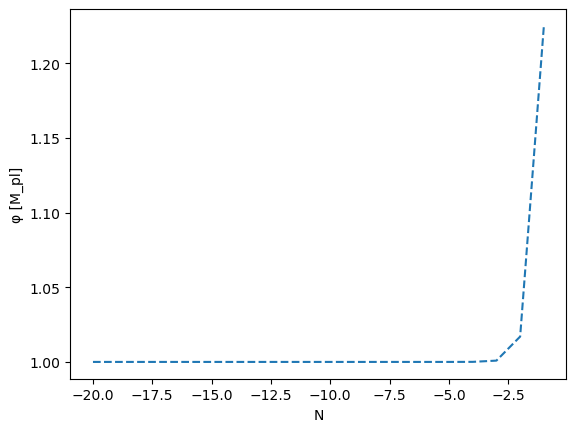

In [30]:
Nrange = np.arange(-20,0,1)
sol = odeint(solveSteinhardtKG,[1,0,rho_c0],t=Nrange)

# Plot of φ against redshift
phi_sol = sol[:,0]
phi_prime = sol[:,1]
Vnumber = sol[:,2]
show(Vnumber)
z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ [M_pl]")
plt.plot(Nrange,phi_sol,'--')

In [7]:
# Multiple Values of Q
def other_parameters(fi,dfi,V,N):
    a = exp(N) # N = ln(a)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*a^(-3)
    H2 = (rho_m + V)/(3-0.5*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + V #Energy density of φ (ρ_φ)
    O_φ = k^2/3*rho_φ/H2 # Ωφ
    Pφ = 0.5*(dfi^2*H2) - V
    w = Pφ/rho_φ #Equation of State wΦ
    y = 0.5*(dfi^2*H2)/V # x In Steinhardt
    return z,rho_φ,Pφ,O_φ,w,y

In [8]:
z,rho,P,om,w,y = other_parameters(phi_sol,phi_prime,Vnumber,Nrange)
Z = z+1

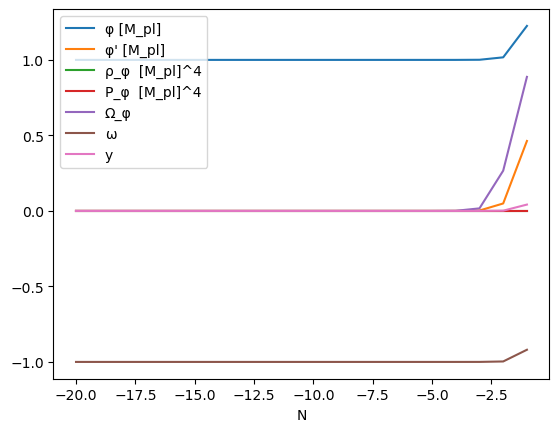

In [9]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

plt.plot(Nrange,phi_sol, label  =r"φ [M_pl]")
plt.plot(Nrange,phi_prime, label  =r"φ' [M_pl]")
plt.plot(Nrange,rho,label=r"ρ_φ  [M_pl]^4")
plt.plot(Nrange,P,label=r"P_φ  [M_pl]^4") 
plt.plot(Nrange,om,label=r"Ω_φ") 
plt.plot(Nrange,w,label=r"ω") 
plt.plot(Nrange,y,label=r"y")
plt.xlabel("N")
plt.legend()

### Oberservations:
Parameters experience a change of shape at N = 0. This is current day. \
$P_φ$ is zero for all N. This makes sense as $P_φ = (γ-1)ρ_φ$ and we have set $γ$ to 1. \
$ρ_φ$ is steadily increases from zero at a constant rate for N less than zero before it has a small rapid expansion at N = 0 before it plateaus. \


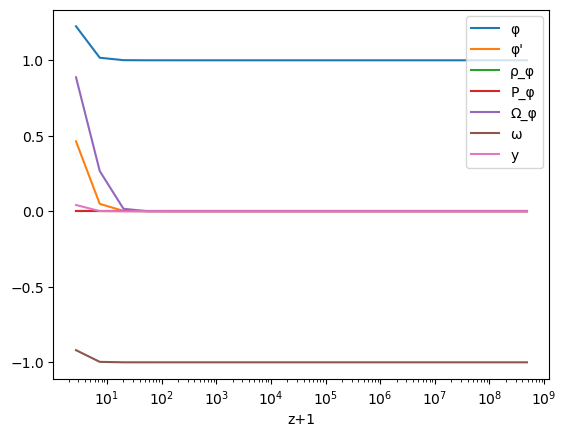

In [10]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1
plt.plot(Z,phi_sol, label  =r"φ")
plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,rho,label=r"ρ_φ")
plt.plot(Z,P,label=r"P_φ") 
plt.plot(Z,om,label=r"Ω_φ") # something wrong as it shouldn't be zero
plt.plot(Z,w,label=r"ω") # interestingly -1 for all z except at current value
plt.plot(Z,y,label=r"y")
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

### Plotting ωφ,ρφ,Ωφ,Pφ values for different initial Q values

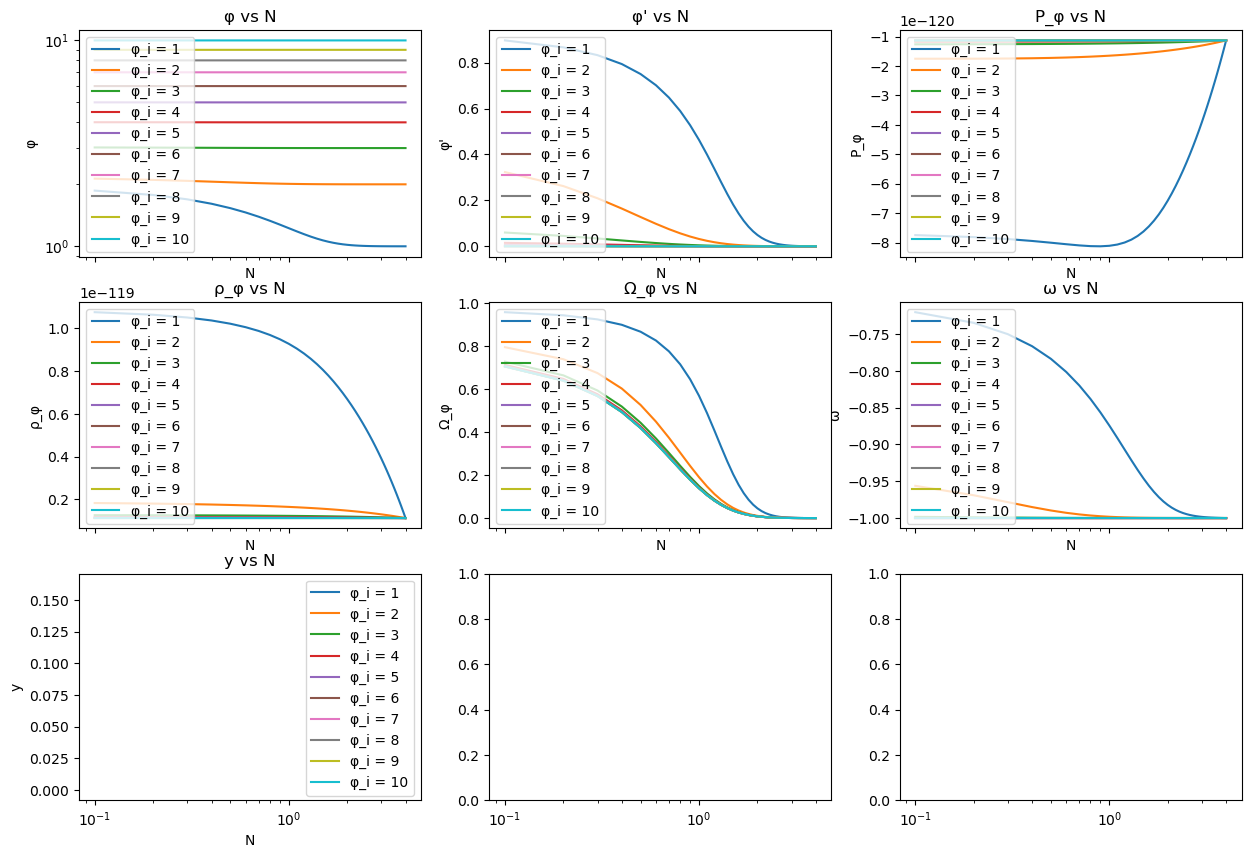

In [11]:
# Test for Attacting Q values
Nrange = np.arange(-4,0,.1)
z_list = []
rho_list = []
P_list = []
om_list = []
w_list = []

fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)

for i in range(1,11,1):
    solQ = odeint(solveSteinhardtKG,[i,0,rho_c0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,om,w,y = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    z_list.append(z);rho_list.append(rho);P_list.append(P);om_list.append(om);w_list.append(w)

    # Use Subplots to observe each parameter over all N for a different intial value of φ
    axs[0,0].plot(-Nrange,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "N",title=r"φ vs N")
    axs[0,0].legend()

    axs[0,1].plot(-Nrange,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "N",title=r"φ' vs N")
    axs[0,1].legend()

    axs[0,2].plot(-Nrange,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "N",title=r"P_φ vs N")
    axs[0,2].legend()

    axs[1,0].plot(-Nrange,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "N",title=r"ρ_φ vs N")
    axs[1,0].legend()

    axs[1,1].plot(-Nrange,om,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "N",title=r"Ω_φ vs N")
    axs[1,1].legend()

    axs[1,2].plot(-Nrange,w,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"ω", xlabel = "N",title=r"ω vs N")
    axs[1,2].legend()

    axs[2,0].plot(Nrange,y,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"y", xlabel = "N",title=r"y vs N")
    axs[2,0].legend()
    

axs[0,0].set_xscale('log')
axs[0,0].set_yscale('log')

#def multipleQ(Q,N):
#axs[0,0].ylabel()
    #axs[0,0].xlabel()    
    

### Improvement to code above:
The code below is the same as the code above, but now allows you to easily choose what is plotted on the x-axis. Also changed the range of N values to include Negative values as well. 

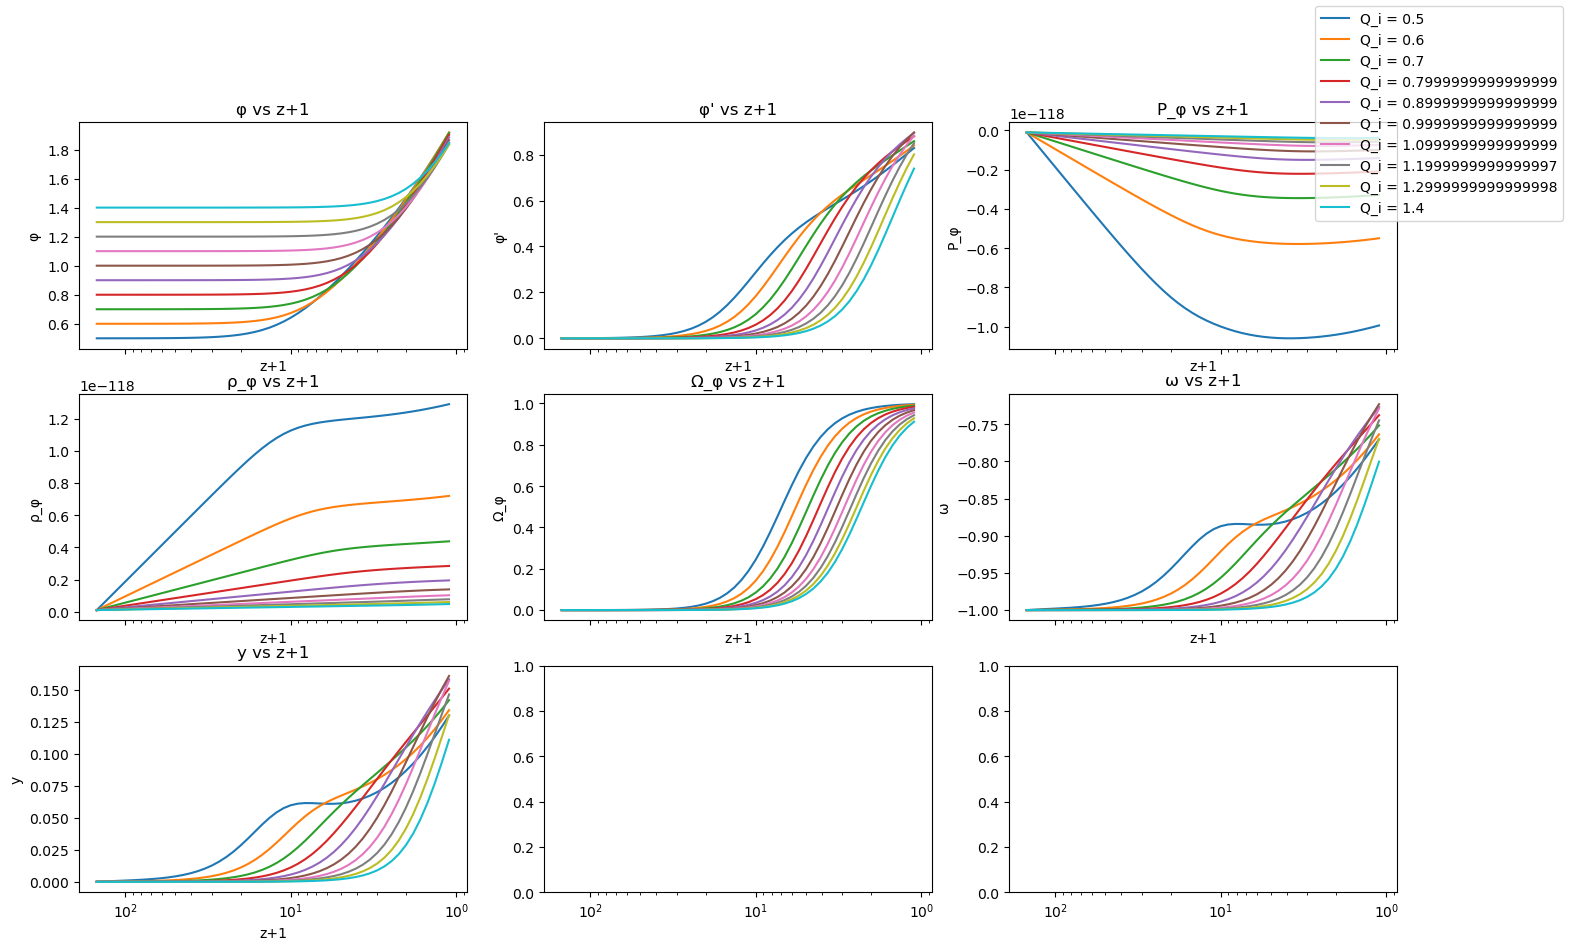

In [12]:
Nrange = np.arange(-5,0,0.1)
Q_values = np.arange(.5,1.5,0.1)
Q_list = []
fig, axs = plt.subplots(3,3, figsize=(17, 10),sharex=True)
def xaxis(x,label,i):
    axs[0,0].set_xscale('log')    
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "{}".format(label),title=r"φ vs {}".format(label))
    if label == "z+1":
        axs[0,0].xaxis.set_inverted(True)
    
    axs[0,1].plot(x,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "{}".format(label),title=r"φ' vs {}".format(label))
    
    axs[0,2].plot(x,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"P_φ vs {}".format(label))
    
    axs[1,0].plot(x,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "{}".format(label),title=r"ρ_φ vs {}".format(label))
    
    axs[1,1].plot(x,om,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "{}".format(label),title=r"Ω_φ vs {}".format(label))
    
    axs[1,2].plot(x,w,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))

    axs[2,0].plot(x,y,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"y", xlabel = "{}".format(label),title=r"y vs {}".format(label))

for i in Q_values:
    if i ==0:
        continue
    else:
        Q_list.append("Q_i = {}".format(i))
        solQ = odeint(solveSteinhardtKG,[i,0,rho_c0],t=Nrange)
        '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ,x values for all initial Q values ranged. '''
        z,rho,P,om,w,y = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
        Z = z+1
        xaxis(Z,"z+1",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1

fig.legend(Q_list)

Qi = 5 and =-10 show perculiar shapes. The shapes are not consistent with the other initial values of φ

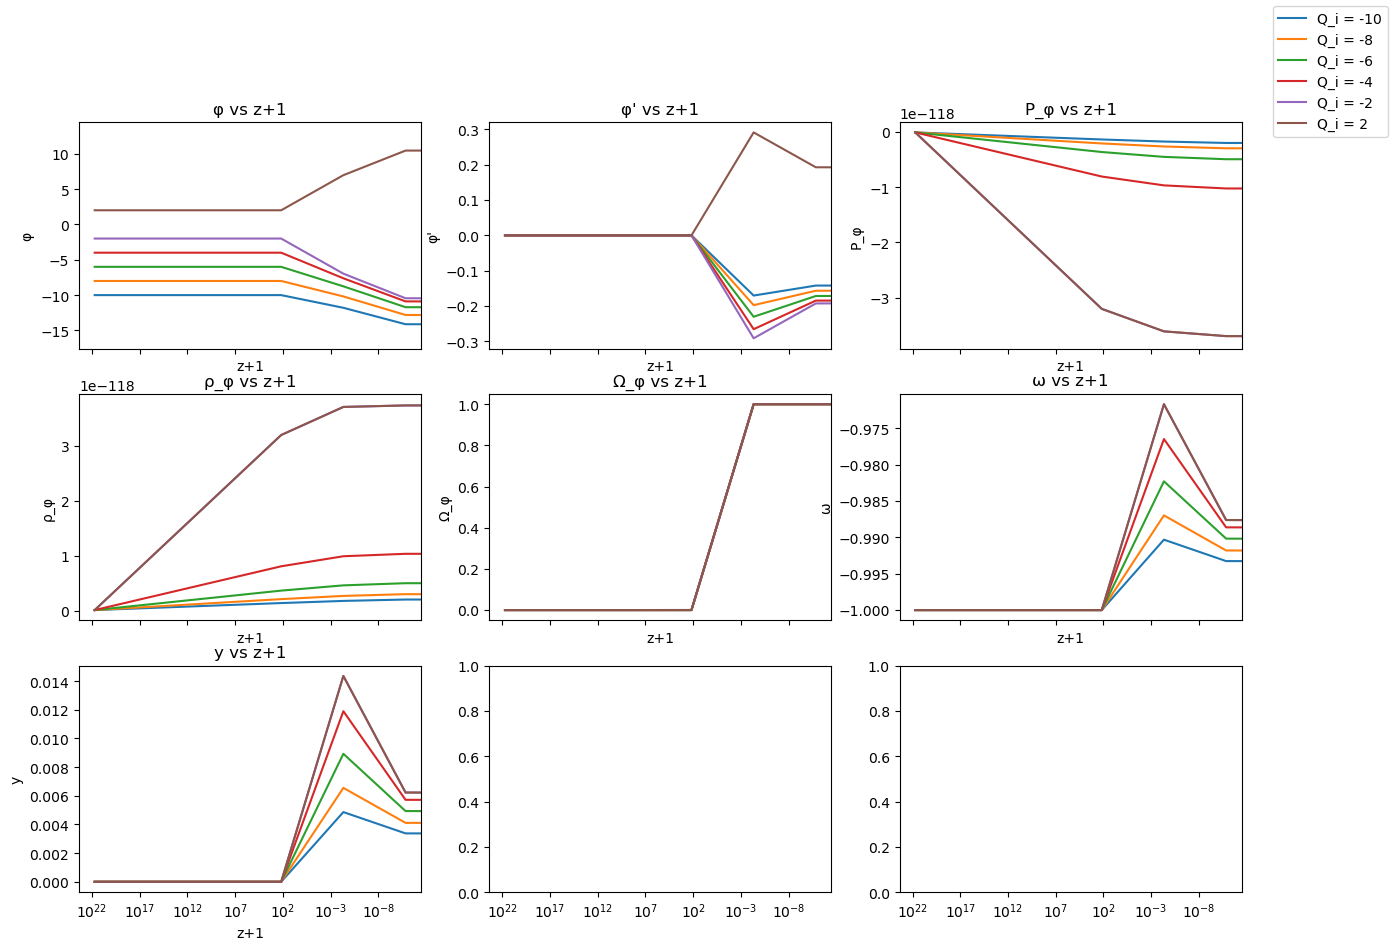

In [28]:
Nrange = np.arange(-50,50,15)
Qvalues = np.arange(-10,4,2)
Q_list = []
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)
for i in Qvalues:
    if i ==0:
        continue
    else:
        Q_list.append("Q_i = {}".format(i))
        solQ = odeint(solveSteinhardtKG,[i,0,rho_c0],t=Nrange)
        z,rho,P,om,w,y = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
        Z = z+1
        xaxis(Z,"z+1",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1
fig.legend(Q_list)

In [61]:
# Gamma:
Gam = var('Γ')
Gam = (V.diff(phi,2))*V/(V.diff(phi))^2
show(Gam)

3/2

In [39]:
# Slow roll parameters: <<1 for inflation
ep = var(r'ε')
ep = 0.5*(V.diff(phi)/V)^2

n = var(r'η')
n = V.diff(phi,2)/V
show(n)

2.00000000000000/φ^2

6/φ^2

In [37]:
# dlnx/dlna:
# N = var('N')
# y =function('y')(N)
# #Y = function(N)
# Y = (ln(y)).diff(N)
# show(Y)

diff(y(N), N)/y(N)